# L13 · Protein Language Models: Zero-Shot Mutation Effects with ESM-2

*Companion notebook for Lecture 13 — Biological Language Models (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Use a pretrained protein language model (ESM-2) as a **masked language model**: hide residues and read the predicted distribution over the 20 amino acids.
2. Score every single mutant of TEM-1 β-lactamase **zero-shot** with the masked marginal $\log p(\text{mut}) - \log p(\text{wt})$ and evaluate it against a deep mutational scan with Spearman ρ.
3. Compare with **supervised ridge baselines** (one-hot features, ESM-2 embeddings) under ProteinGym's random, held-out-position and held-out-region splits, and explain why the random split is optimistic.
4. Embed whole proteins from four Pfam families and check that the embedding recovers family membership better than amino-acid composition.

Runtime: about 1–2 minutes on a laptop CPU with the default ESM-2 8M model (first run also downloads ≈ 30 MB of weights and ≈ 13 MB of ProteinGym data). A GPU is not needed. Setting `MODEL = "35M"` (the first "Try it yourself") takes a few minutes longer.

In [1]:
import os, sys, pathlib, io, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
from course_utils import seed_everything, plot_style, download, device, DATA, PALETTE

# Hugging Face cache inside applications/data/hf (set before transformers is imported; overrides a global HF_HOME)
os.environ["HF_HOME"] = str(DATA / "hf")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
warnings.filterwarnings("ignore", message=".*resume_download.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.stats import spearmanr
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, EsmForMaskedLM
from transformers.utils import logging as hf_logging
from huggingface_hub.utils import logging as hub_logging
hf_logging.set_verbosity_error(); hub_logging.set_verbosity_error()   # silence download/auth notices
pd.set_option("display.width", 140)

rng = seed_everything(0)
plot_style()
dev = device()
print("device:", dev)

MODEL = "8M"            # "8M" (default) or "35M" (Try it yourself). Never 650M: it does not fit in 8 GB RAM.
ASSAY = "BLAT_ECOLX_Stiffler_2015"   # any ProteinGym single-substitution assay (Try it yourself)
MODELS = {"8M": "facebook/esm2_t6_8M_UR50D", "35M": "facebook/esm2_t12_35M_UR50D",
          "150M": "facebook/esm2_t30_150M_UR50D"}
AA = "ACDEFGHIKLMNPQRSTVWY"
SPLITS = [("fold_random_5", "Random variants"), ("fold_modulo_5", "Held-out positions"),
          ("fold_contiguous_5", "Held-out regions")]

device: cpu


## 1. Dataset: a deep mutational scan of TEM-1 β-lactamase

**Biological question.** Which single amino-acid substitutions break a protein, and which are tolerated? TEM-1 β-lactamase (gene *bla*, *E. coli*) hydrolyzes penicillins such as ampicillin and is a major cause of antibiotic resistance.

- **What is measured:** in a *deep mutational scan* (DMS) Stiffler et al. built a library containing nearly every single substitution of TEM-1, expressed it in *E. coli*, and grew the cells on ampicillin. Sequencing before and after selection gives each variant's enrichment: variants that keep the enzyme working survive. ProteinGym uses the 2,500 µg/mL ampicillin measurement.
- **One sample** = one single mutant, written `wt pos mt` (e.g. `S68A`: Ser at UniProt position 68 replaced by Ala).
- **Input** $x$: the mutant sequence (for the zero-shot model) or features of (wt, position, mt) (for ridge). **Target** $y$: `DMS_score`, higher = fitter (more resistance).
- **Why it matters:** a model that ranks mutations without any measurement helps interpret missense variants in genes that have never been scanned.

**Sources and licenses.**
- ProteinGym v1.3 (Notin et al., *NeurIPS* 36, Datasets & Benchmarks, 2023; MIT license), supervised cross-validation archive `cv_folds_singles_substitutions.zip`, which includes ProteinGym's official random / modulo / contiguous 5-fold assignments. Underlying data: Stiffler, Hekstra & Ranganathan, *Cell* 160, 882 (2015).
- ESM-2 checkpoints (Lin et al., *Science* 379, 1123, 2023; MIT license) from Hugging Face (`facebook/esm2_t*_UR50D`).
- Protein sequences for Section 8 from UniProtKB/Swiss-Prot via the UniProt REST API (CC BY 4.0).

Everything is cached in `applications/data/` (`proteingym/`, `hf/`, `L13_protein_families.tsv`).

In [2]:
PG_URL = "https://marks.hms.harvard.edu/proteingym/ProteinGym_v1.3/cv_folds_singles_substitutions.zip"
(DATA / "proteingym").mkdir(exist_ok=True)

def load_assay(name):
    """The DMS table (mutant, DMS_score, folds, pos, wt, mt) and the reconstructed wild-type sequence."""
    from zipfile import ZipFile
    root = DATA / "proteingym"
    csv = root / "cv_folds_singles_substitutions" / f"{name}.csv"
    if not csv.exists():
        z = download(PG_URL, "proteingym/cv_folds_singles_substitutions.zip", timeout=300)
        with ZipFile(z) as zf:
            zf.extract(f"cv_folds_singles_substitutions/{name}.csv", root)
    d = pd.read_csv(csv)
    d["pos"] = d.mutant.str[1:-1].astype(int)
    d["wt"] = d.mutant.str[0]
    d["mt"] = d.mutant.str[-1]
    r = d.iloc[0]
    wt = r.mutated_sequence[:r.pos - 1] + r.wt + r.mutated_sequence[r.pos:]
    assert all(wt[p - 1] == w for p, w in zip(d.pos, d.wt))
    return d, wt

d, wt = load_assay(ASSAY)
y = d.DMS_score.to_numpy()
print(f"{ASSAY}: {len(d):,} single mutants at {d.pos.nunique()} positions ({d.pos.min()}–{d.pos.max()}); "
      f"wild-type length L = {len(wt)}")
print(d[["mutant", "DMS_score", "DMS_score_bin", "fold_random_5", "fold_modulo_5", "fold_contiguous_5"]].head().to_string())

BLAT_ECOLX_Stiffler_2015: 4,996 single mutants at 263 positions (24–286); wild-type length L = 286
  mutant  DMS_score  DMS_score_bin  fold_random_5  fold_modulo_5  fold_contiguous_5
0   H24C  -0.418260              1              3              0                  0
1   H24Y  -0.885025              1              4              0                  0
2   H24W  -1.347586              0              0              0                  0
3   H24V  -0.026874              1              2              0                  0
4   H24T  -0.067188              1              2              0                  0


## 2. Exploration: what does the fitness landscape look like?

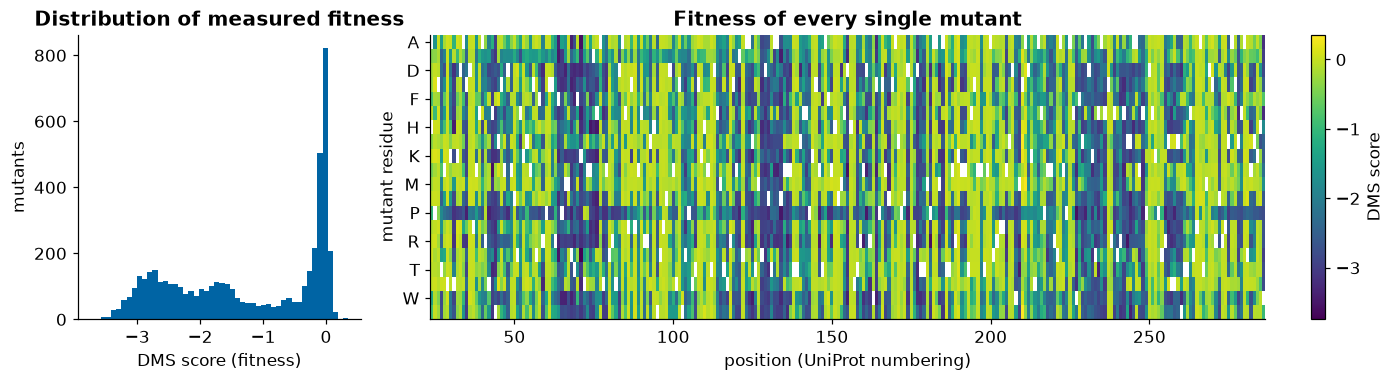

position alone explains η² = 0.63 of the variance (per-position means)


In [3]:
def site_matrix(d, values):
    """20 × positions matrix (rows = mutant amino acid) of a per-variant value; NaN where not measured."""
    pos = np.arange(d.pos.min(), d.pos.max() + 1)
    M = np.full((20, len(pos)), np.nan)
    M[[AA.index(a) for a in d.mt], d.pos.to_numpy() - pos[0]] = values
    return pos, M

pos, M = site_matrix(d, y)
fig, axs = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw=dict(width_ratios=[1, 3.2]))
axs[0].hist(y, bins=50, color=PALETTE[0])
axs[0].set(xlabel="DMS score (fitness)", ylabel="mutants", title="Distribution of measured fitness")
im = axs[1].imshow(M, aspect="auto", cmap="viridis", interpolation="nearest",
                   extent=[pos[0] - 0.5, pos[-1] + 0.5, 19.5, -0.5])
axs[1].set_yticks(range(0, 20, 2)); axs[1].set_yticklabels(list(AA)[::2], fontsize=11)
axs[1].set(xlabel="position (UniProt numbering)", ylabel="mutant residue", title="Fitness of every single mutant")
plt.colorbar(im, ax=axs[1], label="DMS score", fraction=0.03)
plt.tight_layout(); plt.show()

pos_mean = d.groupby("pos").DMS_score.transform("mean").to_numpy()
eta2 = 1 - np.sum((y - pos_mean) ** 2) / np.sum((y - y.mean()) ** 2)
print(f"position alone explains η² = {eta2:.2f} of the variance (per-position means)")

The distribution is bimodal: many mutants keep near–wild-type fitness, a large group is dead. The heat map has **vertical stripes**: some positions (the buried core, the catalytic Ser68 and Lys71) tolerate almost nothing, surface positions tolerate almost everything. Position alone explains about 63% of the variance — keep this number in mind for the supervised baselines in Section 6.

## 3. Preprocessing: tokens and the ESM-2 model
ESM-2 tokenizes a protein one residue per token and adds `<cls>` at the start and `<eos>` at the end, so residue $i$ (1-based) is token $i$. We load the masked-language-model head (`EsmForMaskedLM`).

In [4]:
_cache = {}
def esm(size):
    if size not in _cache:
        tok = AutoTokenizer.from_pretrained(MODELS[size])
        m = EsmForMaskedLM.from_pretrained(MODELS[size]).eval().to(dev)
        _cache[size] = (tok, m)
    return _cache[size]

tok, model = esm(MODEL)
cfg = model.config
n_params = sum(p.numel() for p in model.parameters())
print(f"ESM-2 {MODEL}: {n_params:,} parameters, {cfg.num_hidden_layers} layers, d = {cfg.hidden_size}, "
      f"{cfg.num_attention_heads} heads, vocabulary {cfg.vocab_size}")
print("tokens of 'MVHL':", tok.convert_ids_to_tokens(tok("MVHL")["input_ids"]))
AA_IDS = [tok.convert_tokens_to_ids(a) for a in AA]

ESM-2 8M: 7,512,474 parameters, 6 layers, d = 320, 20 heads, vocabulary 33
tokens of 'MVHL': ['<cls>', 'M', 'V', 'H', 'L', '<eos>']


## 4. Model: masked prediction on human β-globin
The deck's worked example: take the first 14 residues of human β-globin (HBB, `MVHLTPEEKSAVTA`), mask residues 4, 8 and 12 **together** and let the 8M model fill them in using the full 147-residue sequence as context. Then score the sickle-cell substitution **E6V** (Glu6 in mature-protein numbering, index 7 with the initiator Met): mask Glu6 and compare $\log p(\mathrm V)$ with $\log p(\mathrm E)$.

input: M V H _ T P E _ K S A _ T A
  position 4 (true L): L 0.36, F 0.09, A 0.09
  position 8 (true E): Q 0.27, E 0.19, L 0.09
  position 12 (true V): L 0.35, V 0.16, F 0.12

sickle E6V (8M): p(E) = 0.309, p(V) = 0.032, score = log p(V) − log p(E) = -2.28


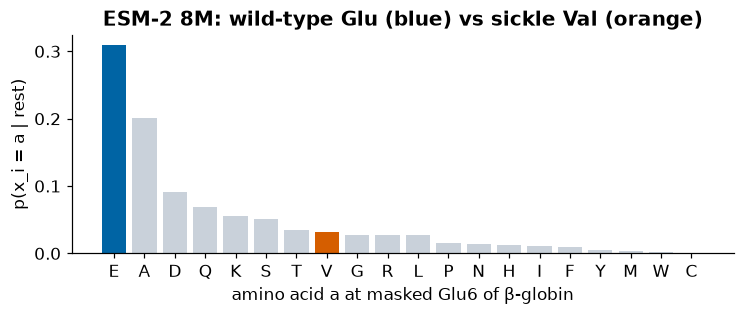

In [5]:
HBB_HUMAN = ("MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSE"
             "LHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH")
MLM_MASK = [3, 7, 11]   # 0-based positions masked together
SICKLE = 6              # 0-based index of Glu6 (mature numbering)

def masked_probs(size, seq, masked):
    """Softmax over the 20 amino acids at the masked positions (all masked in the same forward pass)."""
    tok, m = esm(size)
    x = torch.tensor(tok(seq)["input_ids"])
    for i in masked:
        x[i + 1] = tok.mask_token_id          # +1: <cls> token at the start
    with torch.no_grad():
        p = m(input_ids=x[None].to(dev)).logits.float().softmax(-1)[0].cpu().numpy()
    return {i: p[i + 1, AA_IDS] for i in masked}

pm = masked_probs("8M", HBB_HUMAN, MLM_MASK)
print("input:", " ".join("_" if i in MLM_MASK else a for i, a in enumerate(HBB_HUMAN[:14])))
for i in MLM_MASK:
    top = np.argsort(-pm[i])[:3]
    print(f"  position {i + 1} (true {HBB_HUMAN[i]}): " + ", ".join(f"{AA[j]} {pm[i][j]:.2f}" for j in top))

p6 = masked_probs("8M", HBB_HUMAN, [SICKLE])[SICKLE]
sE, sV = AA.index("E"), AA.index("V")
print(f"\nsickle E6V (8M): p(E) = {p6[sE]:.3f}, p(V) = {p6[sV]:.3f}, "
      f"score = log p(V) − log p(E) = {np.log(p6[sV]) - np.log(p6[sE]):.2f}")
order = np.argsort(-p6)
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(20), p6[order], color=[PALETTE[0] if AA[j] == "E" else PALETTE[5] if AA[j] == "V" else "#C9D1DA"
                                    for j in order])
ax.set_xticks(range(20)); ax.set_xticklabels([AA[j] for j in order])
ax.set(ylabel="p(x_i = a | rest)", xlabel="amino acid a at masked Glu6 of β-globin",
       title="ESM-2 8M: wild-type Glu (blue) vs sickle Val (orange)")
plt.tight_layout(); plt.show()

A negative score means "evolutionarily unusual in this context", not a mechanism: HbS still folds, it causes disease because Val6 creates a sticky patch that makes deoxy-hemoglobin polymerize.

## 5. Training? None — zero-shot scoring of every TEM-1 mutant
ESM-2 was pretrained on UniRef sequences only; it never saw a fitness label. The **masked marginal** score (Meier et al., *NeurIPS* 2021) of mutant `wt i mt` is

$$\text{score} = \log p_\theta(s_i = \text{mt} \mid \mathbf s_{\setminus i}) - \log p_\theta(s_i = \text{wt} \mid \mathbf s_{\setminus i}).$$

One forward pass per masked position gives the full $L \times 20$ table, hence all $19L$ single mutants from $L$ passes (batched 8 at a time). We also compute the one-pass *wild-type marginal* shortcut (no masking).

In [6]:
def masked_logprobs(size, seq, batch=8):
    """log p(x_i = a | x_{-i}) for every position i (mask i, one pass each) → (L, 20), and the
    unmasked (wild-type marginal) log-probabilities → (L, 20)."""
    tok, m = esm(size)
    ids = torch.tensor(tok(seq)["input_ids"])
    n = len(seq)
    mm = np.zeros((n, 20))
    with torch.no_grad():
        for s in range(0, n, batch):
            pos_ = list(range(s, min(n, s + batch)))
            x = ids.repeat(len(pos_), 1)
            for k, i in enumerate(pos_):
                x[k, i + 1] = tok.mask_token_id
            lp = m(input_ids=x.to(dev)).logits.float().log_softmax(-1).cpu()
            for k, i in enumerate(pos_):
                mm[i] = lp[k, i + 1, AA_IDS].numpy()
        wm = m(input_ids=ids[None].to(dev)).logits.float().log_softmax(-1)[0, 1:-1][:, AA_IDS].cpu().numpy()
    return mm, wm

def mutant_scores(d, lp):
    """Masked-marginal score log p(mut) − log p(wt) at the mutated position."""
    i = d.pos.to_numpy() - 1
    return lp[i, [AA.index(a) for a in d.mt]] - lp[i, [AA.index(a) for a in d.wt]]

def fold_mean_spearman(score, y, folds):
    return float(np.mean([spearmanr(score[folds == f], y[folds == f]).statistic for f in sorted(set(folds))]))

t0 = time.time()
mm, wm = masked_logprobs(MODEL, wt)
print(f"{len(wt)} masked forward passes with ESM-2 {MODEL}: {time.time() - t0:.0f} s")
zs = mutant_scores(d, mm)
wt_idx = np.array([AA.index(a) for a in wt])
print(f"masked wild-type recovery (top-1): {np.mean(mm.argmax(1) == wt_idx):.2f}; "
      f"pseudo-perplexity {np.exp(-np.mean(mm[np.arange(len(wt)), wt_idx])):.1f}  (uniform = 20)")

286 masked forward passes with ESM-2 8M: 20 s
masked wild-type recovery (top-1): 0.29; pseudo-perplexity 9.9  (uniform = 20)


## 6. Evaluation
### 6a. Zero-shot Spearman ρ
Model scores and DMS scores are on different scales; Spearman ρ compares only their **ranks**. To compare with the supervised baselines below we also report the mean of ρ over the test folds of each split (zero-shot uses no training data, so it does not depend on the split beyond the fold subsets).

ESM-2 8M zero-shot: Spearman ρ = 0.40 (masked marginal), 0.37 (wild-type marginal)
  5-fold mean ρ, Random variants   : 0.40
  5-fold mean ρ, Held-out positions: 0.40
  5-fold mean ρ, Held-out regions  : 0.40


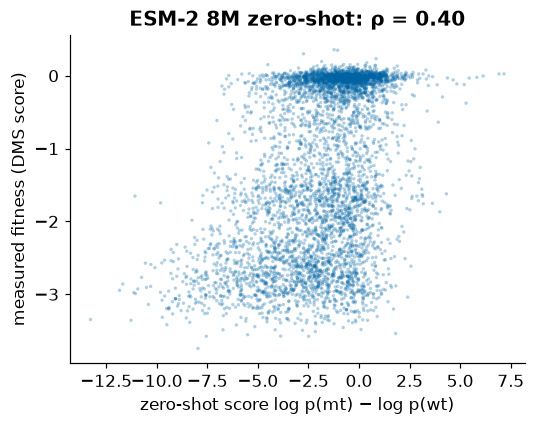

In [7]:
rho_mm = spearmanr(zs, y).statistic
rho_wm = spearmanr(mutant_scores(d, wm), y).statistic
print(f"ESM-2 {MODEL} zero-shot: Spearman ρ = {rho_mm:.2f} (masked marginal), {rho_wm:.2f} (wild-type marginal)")
zs_folds = {c: fold_mean_spearman(zs, y, d[c].to_numpy()) for c, _ in SPLITS}
for c, lab in SPLITS:
    print(f"  5-fold mean ρ, {lab:18s}: {zs_folds[c]:.2f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(zs, y, s=5, alpha=0.3, color=PALETTE[0], edgecolor="none")
ax.set(xlabel="zero-shot score log p(mt) − log p(wt)", ylabel="measured fitness (DMS score)",
       title=f"ESM-2 {MODEL} zero-shot: ρ = {rho_mm:.2f}")
plt.tight_layout(); plt.show()

### 6b. Supervised ridge baselines under three split schemes
With labels, a simple regression model can do much better — but it depends on *what* is held out. ProteinGym ships three official 5-fold schemes:

- **random**: variants assigned to folds at random (the same position appears in train and test);
- **modulo**: position $i$ goes to fold $i \bmod 5$ (test positions are never seen in training);
- **contiguous**: five contiguous blocks of positions (whole regions held out).

Features (as in the lecture): **one-hot** of (wild-type residue, position, mutant residue); **8M embedding**: the ESM-2 last-layer vector of the wild-type residue at the mutated position (from the unmasked wild-type sequence) + one-hot of the mutant residue; and embedding **+ zero-shot score**. Model: standardize, then `RidgeCV` with $\lambda$ chosen from $10^{-2}\dots10^{4}$ inside each training fold.

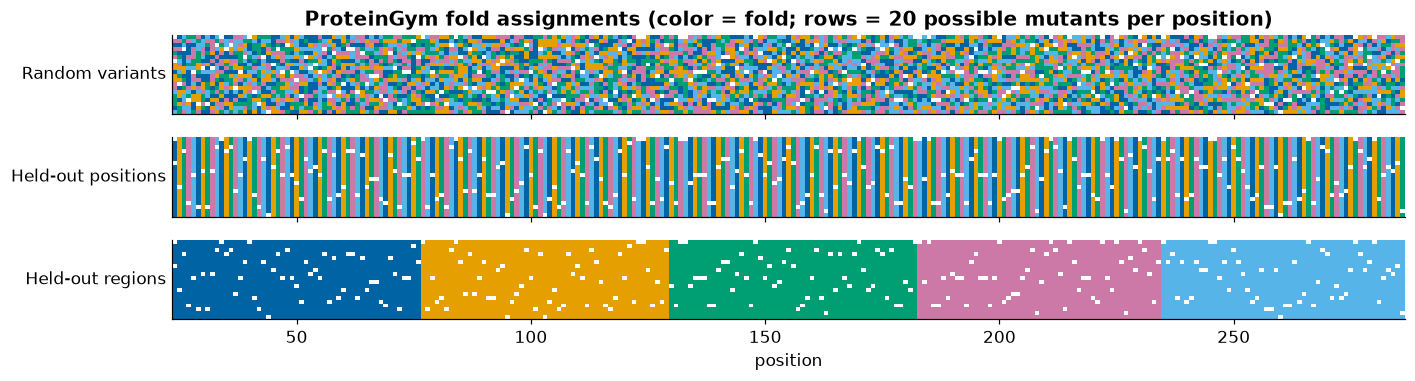

In [8]:
from matplotlib.colors import ListedColormap
fig, axs = plt.subplots(3, 1, figsize=(13, 3.6), sharex=True)
for ax, (col, lab) in zip(axs, SPLITS):
    p_, F = site_matrix(d, d[col].to_numpy())
    ax.imshow(F, aspect="auto", cmap=ListedColormap(PALETTE[:5]), vmin=-0.5, vmax=4.5, interpolation="nearest",
              extent=[p_[0] - 0.5, p_[-1] + 0.5, 19.5, -0.5])
    ax.set_yticks([]); ax.set_ylabel(lab, rotation=0, ha="right", va="center")
axs[0].set_title("ProteinGym fold assignments (color = fold; rows = 20 possible mutants per position)")
axs[-1].set_xlabel("position")
plt.tight_layout(); plt.show()

In [9]:
def onehot_features(d):
    return DictVectorizer().fit_transform(
        [{"wt": w, "pos": str(p), "mt": m} for w, p, m in zip(d.wt, d.pos, d.mt)]).toarray()

def embed_residues(size, seq):
    """(L, d) last-layer representations of one sequence (special tokens dropped)."""
    tok, m = esm(size)
    with torch.no_grad():
        ids = torch.tensor(tok(seq)["input_ids"])[None].to(dev)
        return m.esm(input_ids=ids).last_hidden_state[0, 1:-1].float().cpu().numpy()

def embedding_features(d, H):
    return np.hstack([H[d.pos.to_numpy() - 1], np.eye(20)[[AA.index(a) for a in d.mt]]])

def cv_spearman(X, y, folds):
    rho = []
    for f in sorted(set(folds)):
        tr, te = folds != f, folds == f
        reg = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 13)))
        reg.fit(X[tr], y[tr])
        rho.append(spearmanr(reg.predict(X[te]), y[te]).statistic)
    return float(np.mean(rho)), float(np.std(rho))

H = embed_residues(MODEL, wt)
features = {"one-hot": onehot_features(d), f"{MODEL} embedding": embedding_features(d, H)}
features[f"{MODEL} embedding + zero-shot"] = np.hstack([features[f"{MODEL} embedding"], zs[:, None]])
for k, X in features.items():
    print(f"{k:28s} X ∈ ℝ^{X.shape[0]}×{X.shape[1]}")

t0 = time.time()
res = pd.DataFrame(index=[f"zero-shot {MODEL}"] + list(features), columns=[lab for _, lab in SPLITS], dtype=float)
for col, lab in SPLITS:
    folds = d[col].to_numpy()
    res.loc[f"zero-shot {MODEL}", lab] = zs_folds[col]
    for k, X in features.items():
        res.loc[k, lab] = cv_spearman(X, y, folds)[0]
print(f"(ridge CV: {time.time() - t0:.0f} s)\n\n5-fold mean Spearman ρ")
print(res.round(2).to_string())

one-hot                      X ∈ ℝ^4996×303
8M embedding                 X ∈ ℝ^4996×340
8M embedding + zero-shot     X ∈ ℝ^4996×341


(ridge CV: 21 s)

5-fold mean Spearman ρ
                          Random variants  Held-out positions  Held-out regions
zero-shot 8M                         0.40                0.40              0.40
one-hot                              0.81                0.34              0.33
8M embedding                         0.81                0.36              0.34
8M embedding + zero-shot             0.85                0.42              0.45


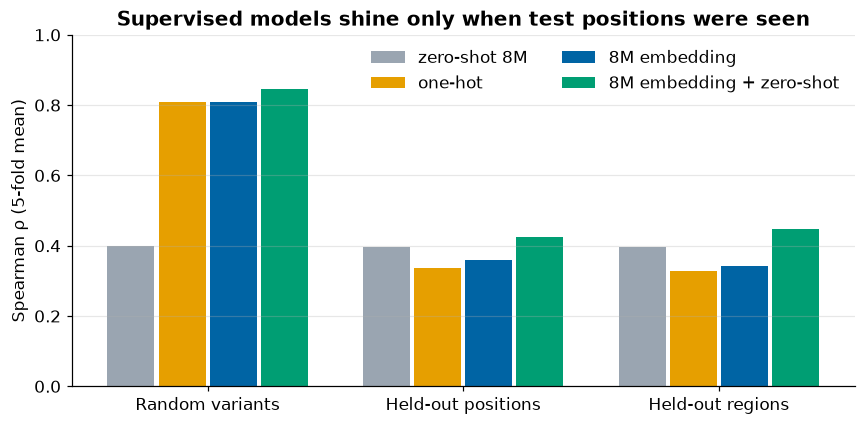

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
w = 0.2
colors = ["#9AA5B1", PALETTE[1], PALETTE[0], PALETTE[2]]
for k, (name, row) in enumerate(res.iterrows()):
    ax.bar(np.arange(3) + (k - 1.5) * w, row.to_numpy(), w * 0.92, color=colors[k], label=name)
ax.set_xticks(range(3)); ax.set_xticklabels(res.columns)
ax.set(ylabel="Spearman ρ (5-fold mean)", ylim=(0, 1),
       title="Supervised models shine only when test positions were seen")
ax.legend(fontsize=11, ncol=2, loc="upper right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the table** (numbers quoted for the default `MODEL = "8M"`). Under the random split, ridge on one-hot features reaches ρ ≈ 0.8: other mutants at the same position are in the training set, and position alone explains ~63% of the variance, so the model mostly learns "which positions are fragile". Under held-out positions or regions this information is gone and one-hot ridge falls to ≈ 0.33 — below the zero-shot 8M model's 0.40 (0.56 for 35M, 0.66 for 150M in the deck). The embedding carries information about the *context* of a position, and adding the zero-shot score to the features helps most where it matters: on unseen positions (0.42) and regions (0.45). A random variant split is therefore optimistic for a new protein or new sites.

**Numbers in the deck.** All 8M numbers above match the deck. The deck's zero-shot 35M (0.56) and 150M (0.66) values come from the lecture build (150M on a GPU, not run here). With `MODEL = "35M"` this notebook gives zero-shot ρ = 0.56 and, for ridge on the 35M embedding, 0.81 / 0.60 / 0.52 (+ zero-shot: 0.86 / 0.64 / 0.56) — the larger model's embedding transfers much better to unseen positions (about 3 min on a 4-thread CPU).

## 7. Visualization: where does the zero-shot model agree with the experiment?

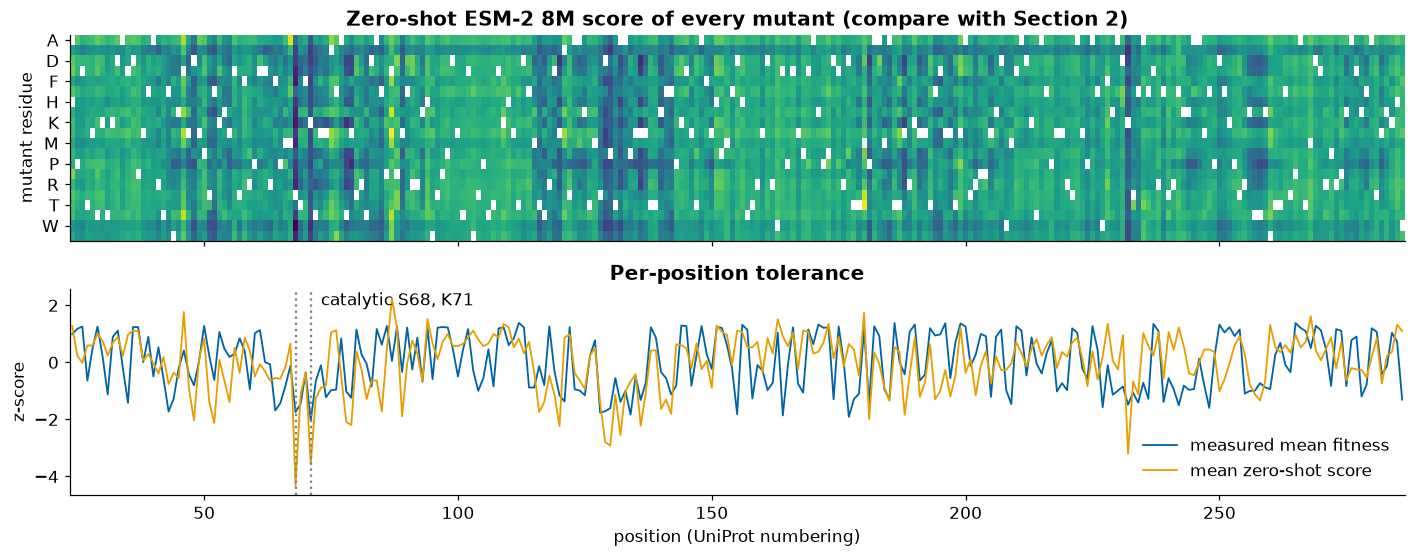

per-position Spearman ρ (mean zero-shot score vs mean fitness): 0.39


In [11]:
_, Z = site_matrix(d, zs)
pos_zs = pd.Series(zs, index=d.pos).groupby(level=0).mean()
pos_fit = d.groupby("pos").DMS_score.mean()
fig, axs = plt.subplots(2, 1, figsize=(13, 5.2), sharex=True)
axs[0].imshow(Z, aspect="auto", cmap="viridis", interpolation="nearest",
              extent=[pos[0] - 0.5, pos[-1] + 0.5, 19.5, -0.5])
axs[0].set_yticks(range(0, 20, 2)); axs[0].set_yticklabels(list(AA)[::2], fontsize=11)
axs[0].set(ylabel="mutant residue", title=f"Zero-shot ESM-2 {MODEL} score of every mutant (compare with Section 2)")
axs[1].plot(pos_fit.index, (pos_fit - pos_fit.mean()) / pos_fit.std(), color=PALETTE[0], lw=1.2,
            label="measured mean fitness")
axs[1].plot(pos_zs.index, (pos_zs - pos_zs.mean()) / pos_zs.std(), color=PALETTE[1], lw=1.2,
            label="mean zero-shot score")
for p_ in (68, 71):
    axs[1].axvline(p_, color="grey", ls=":")
axs[1].text(73, 2.0, "catalytic S68, K71", fontsize=11)
axs[1].set(xlabel="position (UniProt numbering)", ylabel="z-score", title="Per-position tolerance")
axs[1].legend(fontsize=11, loc="lower right")
plt.tight_layout(); plt.show()
print(f"per-position Spearman ρ (mean zero-shot score vs mean fitness): "
      f"{spearmanr(pos_zs.loc[pos_fit.index], pos_fit).statistic:.2f}")

## 8. Embedding whole proteins from four families
Mean-pooling the per-residue representations gives one vector per protein. We take 25 reviewed UniProt entries (length 100–700) from each of four Pfam families, sampled with a fixed seed exactly as in the lecture, and compare two representations with leave-one-out 1-nearest-neighbor (1-NN) family accuracy (cosine distance on standardized features): amino-acid composition (20-d) and the ESM-2 mean embedding.

The list is saved as `applications/data/L13_protein_families.tsv` on the first run. It is sampled from the current UniProt release, so a new release can change which 100 proteins are drawn (the deck used release 2026_03).

                              count  min  50%  max
family                                            
Class A β-lactamase              25  279  291  321
Globin                           25  140  146  458
Protein kinase                   25  358  472  661
Trypsin-like serine protease     25  231  275  566


embedded 100 proteins in 8 s
amino-acid composition (20-d)            1-NN family accuracy 96%
ESM-2 8M mean embedding (320-d)          1-NN family accuracy 100%


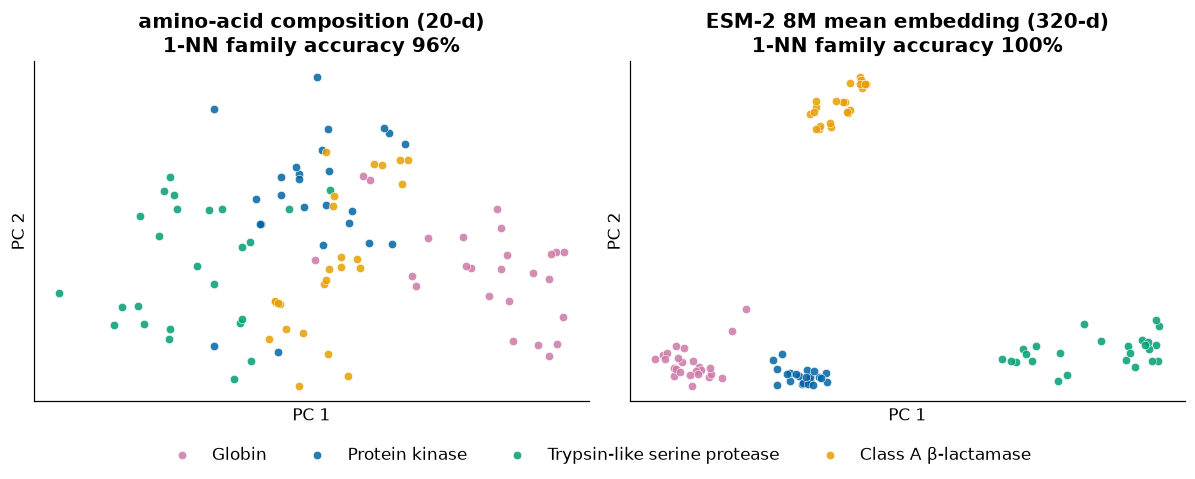

In [12]:
FAMILIES = {"Globin": "PF00042", "Protein kinase": "PF00069", "Trypsin-like serine protease": "PF00089",
            "Class A β-lactamase": "PF13354"}
FAM_COLORS = {"Globin": PALETTE[3], "Protein kinase": PALETTE[0], "Trypsin-like serine protease": PALETTE[2],
              "Class A β-lactamase": PALETTE[1]}
FAMILY_TSV = DATA / "L13_protein_families.tsv"

def families():
    """Four Pfam families, 25 reviewed UniProt entries each (length 100–700), sampled with a fixed seed."""
    import requests
    if not FAMILY_TSV.exists():
        rows = []
        for fam, pf in FAMILIES.items():
            url = ("https://rest.uniprot.org/uniprotkb/search?query=(xref:pfam-" + pf + ")+AND+(reviewed:true)+AND+"
                   "(length:%5B100+TO+700%5D)&fields=accession,id,protein_name,organism_name,length,sequence"
                   "&format=tsv&size=500")
            t = pd.read_csv(io.StringIO(requests.get(url, timeout=120).text), sep="\t")
            t = t.sort_values("Entry").reset_index(drop=True)
            idx = np.random.default_rng(0).choice(len(t), 25, replace=False)
            s = t.iloc[sorted(idx)].copy()
            s["family"], s["pfam"] = fam, pf
            rows.append(s)
        pd.concat(rows).to_csv(FAMILY_TSV, sep="\t", index=False)
    return pd.read_csv(FAMILY_TSV, sep="\t")

def embed_proteins(size, seqs):
    return np.stack([embed_residues(size, s).mean(0) for s in seqs])

def loo_1nn(X, lab):
    """Leave-one-out 1-nearest-neighbor accuracy (cosine distance on standardized features)."""
    Z = (X - X.mean(0)) / (X.std(0) + 1e-8)
    Z = Z / np.linalg.norm(Z, axis=1, keepdims=True)
    D = 1 - Z @ Z.T
    np.fill_diagonal(D, np.inf)
    return float(np.mean(lab[D.argmin(1)] == lab))

fam = families()
lab = fam.family.to_numpy()
print(fam.groupby("family").Length.describe()[["count", "min", "50%", "max"]].astype(int))
t0 = time.time()
reps = {"amino-acid composition (20-d)": np.stack([[s.count(a) / len(s) for a in AA] for s in fam.Sequence]),
        f"ESM-2 {MODEL} mean embedding ({cfg.hidden_size}-d)": embed_proteins(MODEL, list(fam.Sequence))}
print(f"embedded {len(fam)} proteins in {time.time() - t0:.0f} s")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (name, X) in zip(axs, reps.items()):
    acc = loo_1nn(X, lab)
    print(f"{name:40s} 1-NN family accuracy {100 * acc:.0f}%")
    Z2 = PCA(2).fit_transform((X - X.mean(0)) / (X.std(0) + 1e-8))
    for fm, c in FAM_COLORS.items():
        k = lab == fm
        ax.scatter(Z2[k, 0], Z2[k, 1], s=30, color=c, label=fm, alpha=0.85, edgecolor="white", lw=0.4)
    ax.set(title=f"{name}\n1-NN family accuracy {100 * acc:.0f}%", xlabel="PC 1", ylabel="PC 2",
           xticks=[], yticks=[])
fig.legend(*axs[0].get_legend_handles_labels(), loc="lower center", ncol=4, fontsize=11)
plt.tight_layout(rect=(0, 0.07, 1, 1)); plt.show()

## 9. Biological interpretation

- **Why can a model with no fitness labels rank mutations at all?** Evolution keeps sequences that fold and function. A model trained to fill in masked residues across millions of natural proteins learns which residues are plausible in which context; an implausible substitution is often a damaging one. The zero-shot score captures mostly *which positions* are constrained (compare the per-position curves above) and, to a lesser extent, which substitutions at a position are chemically acceptable.
- **Model size matters**: masked wild-type recovery and ρ rise from 8M → 35M → 150M (deck: 0.40 → 0.56 → 0.66).
- **Split choice changes the question.** "Random variants" asks: can you fill in a partially measured DMS? "Held-out positions/regions" asks something closer to predicting effects at sites never measured. The one-hot model cannot generalize to a new position by construction — its position indicator has never been seen.
- **Embeddings organize protein space by family** even though ESM-2 was never told about Pfam. Composition already separates some families (globins are small and helical), but the embedding is more consistent.
- **Caveats.** TEM-1 has many homologs in UniRef, close to the best case for a language model; a DMS measures one selective condition (growth on ampicillin), not clinical pathogenicity; zero-shot scores flag "evolutionarily unusual", which is not the same as disease-causing (loss-of-function variants that matter only late in life, or gain-of-function variants, can look plausible). No clinical claims follow from this notebook.

## 10. Try it yourself

1. **Switch to the 35M model.** Set `MODEL = "35M"` in the first code cell and rerun. How much do the zero-shot ρ and the embedding-based ridge change? (deck: 0.40 → 0.56 zero-shot)
2. **Try another ProteinGym assay.** Set `ASSAY` to another name in `applications/data/proteingym/cv_folds_singles_substitutions/` (e.g. `"P53_HUMAN_Kotler_2018"`, `"PTEN_HUMAN_Mighell_2018"`, `"CBS_HUMAN_Sun_2020"`). Does the gap between random and held-out-position splits persist? (ESM-2 accepts at most 1,022 residues; pick a protein shorter than that.) Some assays are much harder: on `P53_HUMAN_Kotler_2018` the 8M zero-shot ρ is only ≈ 0.10, while ridge still reaches 0.64 on random variants vs 0.30 on held-out positions.
3. Replace the masked marginal by the one-pass **wild-type marginal** score (`mutant_scores(d, wm)`) in the ridge features. How much is lost, and how much faster is it?
4. Change the family 1-NN to use **cosine distance on the raw embedding** (no standardization), or reduce to 10 proteins per family. Is the embedding advantage robust?
5. *(CS284A)* Show that the masked marginal is a log-odds ratio $\log \frac{p(\text{mt}\mid \mathbf s_{\setminus i})}{p(\text{wt}\mid \mathbf s_{\setminus i})}$ and sum it over positions for a double mutant. Why is this an approximation (independence of sites)? Compute the pseudo-log-likelihood of the mutant sequence instead for a few mutants and compare.